In [8]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import json
import datasets
import matplotlib.pyplot as plt
import torch
import numpy as np
import PIL
import albumentations as A


from project_root import DATASETS_ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
###########################################################################
# Test model
from transformers import (
    AutoModelForImageClassification,
    AutoImageProcessor,
)

# id2label = {i: f"c{i}" for i in range(80)}
# model = Mask2FormerForUniversalSegmentation.from_pretrained(
#     "facebook/mask2former-swin-base-coco-panoptic",
#     id2label=id2label,
#     ignore_mismatched_sizes=True,
# )
# from transformers import AutoImageProcessor

# image_processor = AutoImageProcessor.from_pretrained(
#     "facebook/mask2former-swin-base-coco-panoptic"
# )

model_path = Path("/home/dherrera/git/zoo_vision/models/sleep/vit/mix/")
model = AutoModelForImageClassification.from_pretrained(
    model_path,
)

image_processor = AutoImageProcessor.from_pretrained(model_path)
image_size = image_processor.size
print(f"{image_size=}")

image_size={'height': 224, 'width': 224}


In [10]:
print(image_processor)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48500001430511475,
    0.4560000002384186,
    0.4059999883174896
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.2290000021457672,
    0.2239999920129776,
    0.22499999403953552
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [11]:
import torchinfo

torchinfo.summary(
    model,
    input_size=[3, image_size["height"], image_size["width"]],
    batch_dim=0,
    depth=10,
)

Layer (type:depth-idx)                                  Output Shape              Param #
ViTForImageClassification                               [[1, 3]]                  --
├─ViTModel: 1-1                                         [[1, 197, 768]]           --
│    └─ViTEmbeddings: 2-1                               [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                     [1, 196, 768]             --
│    │    │    └─Conv2d: 4-1                            [1, 768, 14, 14]          590,592
│    │    └─Dropout: 3-2                                [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                  [[1, 197, 768]]           --
│    │    └─ModuleList: 3-3                             --                        --
│    │    │    └─ViTLayer: 4-2                          [1, 197, 768]             --
│    │    │    │    └─LayerNorm: 5-1                    [1, 197, 768]             1,536
│    │    │    │    └─ViTAttention: 5-2        

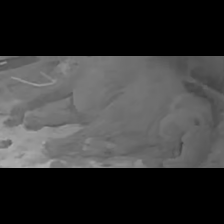

In [ ]:
im_path = "/media/dherrera/ElephantExternal/elephants/tracks/new/zag_elp_cam_016_20230822_030005_t2_21.png"
im = np.asarray(PIL.Image.open(im_path).convert("RGB")).copy()
im[0:56, :, :] = 0
im[-56:, :, :] = 0
image = PIL.Image.fromarray(im)
image
# model.forward()

In [17]:
preprocess_mean = (
    np.asarray(
        [0.48500001430511475, 0.4560000002384186, 0.4059999883174896], dtype=np.float32
    )
    * 255
)
preprocess_std = (
    np.asarray(
        [0.2290000021457672, 0.2239999920129776, 0.22499999403953552], dtype=np.float32
    )
    * 255
)

# imt = A.Normalize(mean=preprocess_mean, std=preprocess_std)(image=im)["image"]
imt = (im.astype(np.float32) - preprocess_mean[None, None, :]) / preprocess_std[
    None, None, :
]
imt = torch.from_numpy(imt)
imt = imt.permute([2, 0, 1])
imt = imt.unsqueeze(0)

# data = image_processor.preprocess(im)
# imt = np.stack(data["pixel_values"])
# imt = torch.from_numpy(imt)

data = {"pixel_values": imt}
print(imt.shape)

torch.Size([1, 3, 224, 224])


In [18]:
model = model.cuda()
pixel_values = data["pixel_values"].cuda()
# batch = norm_uint8(batch.)
# batch = image_processor.preprocess(images=image, return_tensors="pt")
with torch.no_grad():
    res_dict = model.forward(pixel_values)
logits = res_dict.logits.cpu()
logits

tensor([[-5.4569,  6.0568, -2.4918]])

In [15]:
# class_queries_logits = res.class_queries_logits[0].cpu()
# masks_queries_logits = res.masks_queries_logits[0].cpu()

# scores = torch.nn.functional.softmax(class_queries_logits, dim=-1)
# scores = scores[:, :-1].flatten(0, 1)
# valid_scores = scores > 0.8
# print(f"{torch.nonzero(valid_scores)=}")

# m1 = masks_queries_logits[50]
# m2 = masks_queries_logits[94]
# area1 = torch.sum(m1>0)
# area2 = torch.sum(m2>0)
# print(area1,area2)
# plt.imshow(m2>0)
# plt.show()

# cmax,_ = class_queries_logits.max(dim=-1)
# cm = cmax[:,None,None] * (masks_queries_logits>0)
# cms = torch.nn.functional.softmax(cm, dim=0)
# cmsi = torch.argmax(cms, dim=0)
# print(cmsi.shape)
# areas = {int(id): int((cmsi==id).sum()) for id in cmsi.unique()}
# print(areas)
# a = torch.zeros(cmsi.shape)
# for idx in torch.nonzero(valid_scores):
#   a[cmsi==idx] = idx
# print(cmsi.unique())
# # h=plt.imshow(cmsi==85)
# h=plt.imshow(masks_queries_logits[85]>0)
# print(class_queries_logits[85])
# print(class_queries_logits[15])
# plt.colorbar(h)
# plt.show()
# # plt.imshow(masks_queries_logits[94] > 0)

In [16]:
count = len(pres[0]["segments_info"])
ncols = min(6, count)
nrows = int(np.ceil(count / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=[20, 10])
axs = np.asarray(axs).flatten()
for i in range(count):
    info = pres[0]["segments_info"][i]
    mask = pres[0]["segmentation"].numpy() == i
    axs[i].imshow(mask[:, :, None] * image)
    axs[i].set_title(f"Class {info['label_id']}")
    axs[i].axis("off")
fig.tight_layout()

NameError: name 'pres' is not defined

masks_queries_logits.shape=torch.Size([100, 150, 270])
class_queries_logits.shape=torch.Size([100, 2])
scores.shape=torch.Size([100, 2]), scores[0,:]=tensor([9.7528e-04, 9.9902e-01])
scores.shape=torch.Size([100]), scores[0]=tensor(0.0010)
torch.nonzero(valid_scores)=tensor([[15],
        [50],
        [94]])


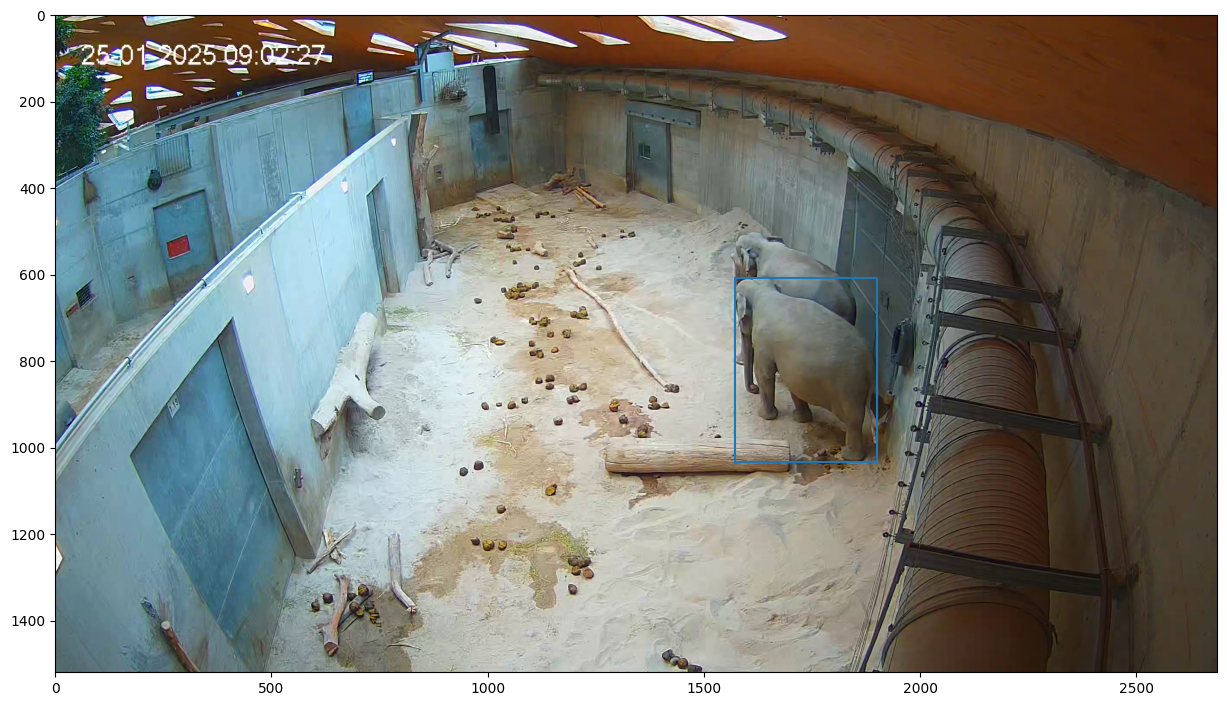

In [ ]:
masks_queries_logits = res.masks_queries_logits[0].to(torch.device("cpu"))
class_queries_logits = res.class_queries_logits[0].to(torch.device("cpu"))
print(f"{masks_queries_logits.shape=}")
print(f"{class_queries_logits.shape=}")

scores = torch.nn.functional.softmax(class_queries_logits, dim=-1)
print(f"{scores.shape=}, {scores[0,:]=}")
scores = scores[:, :-1].flatten(0, 1)
print(f"{scores.shape=}, {scores[0]=}")
valid_scores = scores > 0.8
print(f"{torch.nonzero(valid_scores)=}")

scores = scores[valid_scores]
masks_queries_logits = masks_queries_logits[valid_scores]

mask = masks_queries_logits[0]
mask[mask < 0] = 0

from scripts.datasets.segmentation_utils import (
    bbox_xyxy_from_mask_torch,
    plot_bbox_xyxy,
)

bbox = bbox_xyxy_from_mask_torch(mask).to(torch.float)

scale = np.mean([im.shape[1] / mask.shape[1], im.shape[0] / mask.shape[0]])
# bbox *= scale
bbox[0] *= im.shape[1] / mask.shape[1]
bbox[2] *= im.shape[1] / mask.shape[1]
bbox[1] *= im.shape[0] / mask.shape[0]
bbox[3] *= im.shape[0] / mask.shape[0]

fig, ax = plt.subplots(1, 1, figsize=[15, 10])
ax.imshow(im)
# ax.imshow(A.resize(mask.numpy(), im.shape[:-1], interpolation=2), alpha=0.6)
plot_bbox_xyxy(ax, bbox)

torch.nonzero(valid_scores)=tensor([[15],
        [34],
        [50]])


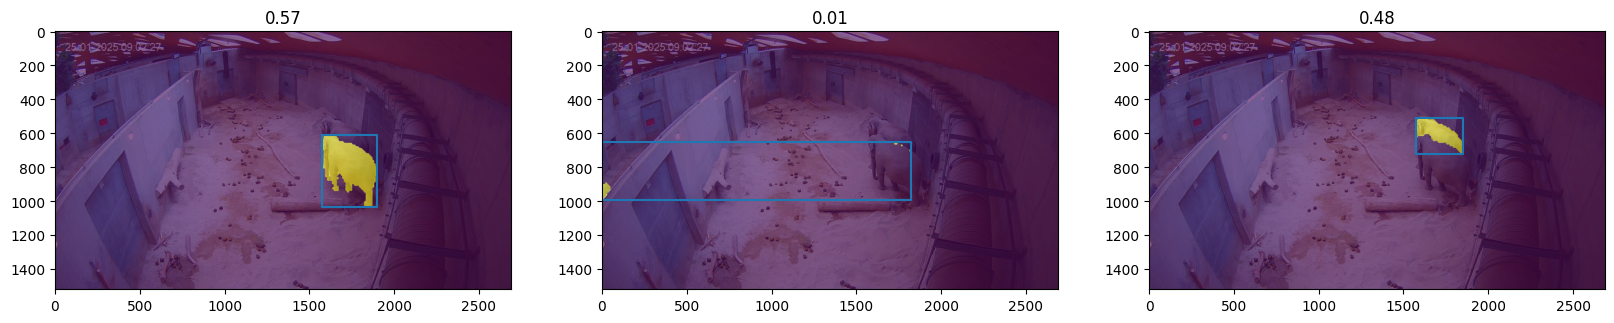

In [ ]:
from mask2former_adapter import Mask2FormerAdapter

jit_model = torch.jit.load(
    model_path / "config.ptc",
)
res_adapter = jit_model(pixel_values)

scores = res_adapter["scores"].cpu()
masks = res_adapter["masks"].cpu()
bboxes = res_adapter["boxes"].cpu().to(torch.float32)
valid_scores = scores > 0.8
print(f"{torch.nonzero(valid_scores)=}")

scores = scores[valid_scores]
masks = masks[valid_scores]
bboxes = bboxes[valid_scores]


scale_x = im.shape[1] / mask.shape[1]
scale_y = im.shape[0] / mask.shape[0]

mask_count = masks.shape[0]
ncols = min(6, count)
nrows = int(np.ceil(count / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=[20, 10])
axs = np.asarray(axs).flatten()
for ax, mask_idx in zip(axs, range(mask_count)):
    mask = masks[mask_idx]
    bbox = bboxes[mask_idx]

    bbox_area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
    area = torch.sum(mask).int() / bbox_area

    # bbox = bbox_from_mask_torch(mask).to(torch.float32)
    # bbox[0],bbox[1] = bbox[1],bbox[0]
    # bbox[2],bbox[3] = bbox[3],bbox[2]
    # bbox *= scale
    bbox[0] *= scale_x
    bbox[2] *= scale_x
    bbox[1] *= scale_y
    bbox[3] *= scale_y

    ax.set_title(f"{area:.2f}")
    ax.imshow(im)
    ax.imshow(A.resize(mask.numpy(), im.shape[:-1], interpolation=2), alpha=0.6)
    plot_bbox_xyxy(ax, bbox)